In [ ]:
# Standard library imports
import warnings

# Data science and statistics imports
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.decomposition import PCA
from kneed import KneeLocator as kl

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

# Single-cell analysis imports
import scanpy as sc

# Ignore warning messages for cleaner notebook output
warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


### Analysis of Gene–Gene Correlation Patterns in a Selected Cell Type

This notebook focuses on exploring the **co-expression structure of genes** within a specific cell type from a single-cell RNA-seq dataset.  
The main goal is to identify **sets of genes that are strongly correlated** within that population, which may reflect shared regulatory programs or biological functions.

#### Overview of the workflow:
1. **Subset the dataset** (`AnnData` object) to a desired cell type (e.g., *Fibroblast*).  
2. **Extract the expression matrix** and filter out genes with zero variance.  
3. **Compute the gene–gene correlation matrix** using Pearson correlation.  
4. **Select the top N most correlated genes** based on their mean correlation with all others.  
5. **Visualize the resulting submatrix** as a heatmap to highlight co-expression modules.

#### Objective:
To characterize the internal structure of gene co-expression within a given cell type,  
providing insight into **potentially co-regulated genes or shared biological pathways**.

The resulting heatmap visually summarizes how strongly genes relate to one another,  
helping identify **clusters of genes** with coordinated expression patterns.


In [ ]:
# Define new function that finds the elbow dimension
def PCA_Elbow_fit(data):
    model = PCA().fit(data)
    explained_variance = model.explained_variance_ratio_
    pcs = list(range(1, explained_variance.shape[0]+1))#enumerate(explained_variance,1)
    klm = kl(pcs, explained_variance, S=1.0, curve='convex', direction='decreasing')
    pcs_used = klm.knee
    pc_list = list(range(1, pcs_used+1))
    new_data = PCA(n_components= pcs_used, svd_solver='arpack').fit_transform(data)

    if pcs_used >50:
        pcs_used=50

    return pcs_used, new_data, pcs, explained_variance, pc_list

### ADATA REAL

In [3]:
adata = sc.read_h5ad("/home/app/datos/PENG/adata_raw_anotado_peng_julio.h5ad")
adata.obs["cell_origin"] = "real"

### Process adata

In [ ]:
# qc filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalization of gene expression counts across cells
adata.layers['counts'] = csr_matrix(adata.X)
adata.raw = adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

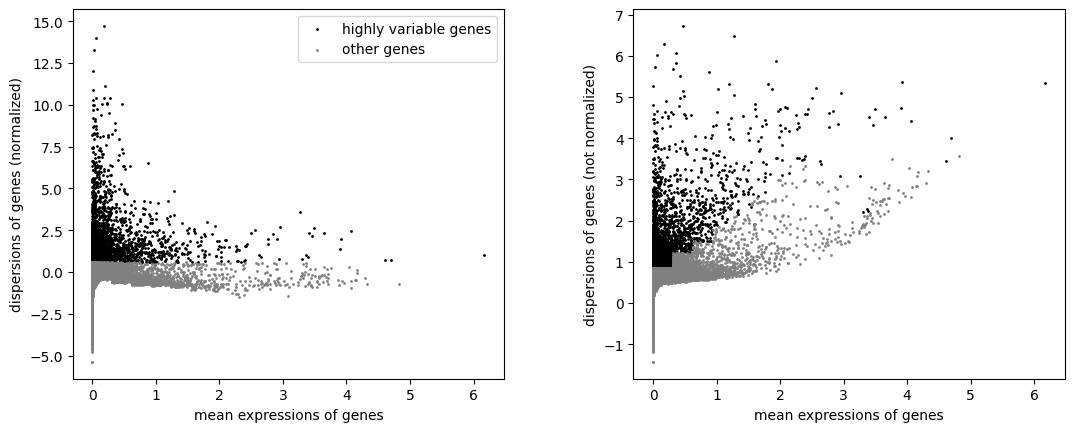

In [8]:
#Record highly variable genes (HVGs)
sc.pp.highly_variable_genes(adata,n_top_genes=3000)
sc.pl.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable].copy()

In [9]:
# Save list of highly variable genes (HVGs)
hvg = list(adata.var_names)

In [11]:
#Reload ADATA REAL
adata = sc.read_h5ad("/home/app/datos/PENG/adata_raw_anotado_peng_julio.h5ad")
adata.obs["cell_origin"] = "real"

In [12]:
# qc filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
#HVGs filtering
adata = adata[:, adata.var_names.isin(hvg)].copy()
# Normalization of gene expression counts across cells
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

Optimal number of PCs: 50


2025-10-13 17:53:14.933064: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-13 17:53:14.941716: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760377994.956065   10485 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760377994.960327   10485 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760377994.971486   10485 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760377994.971508   10485 computation_placer.cc:177] computation placer already registered. Please che

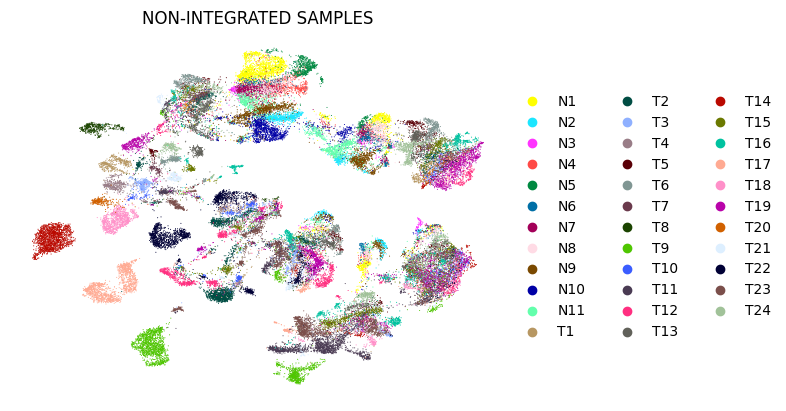

In [17]:
# PCA and UMAP visualization of the dataset

# Convert sparse matrix (if any) to a dense NumPy array for downstream processing
adata.X = np.asarray(adata.X)

# Perform Principal Component Analysis (PCA) to reduce dimensionality
# and capture the main axes of biological variation in the data.
sc.tl.pca(adata, svd_solver="arpack")

# Extract the cell-by-gene expression matrix from the AnnData object
# and convert it into a pandas DataFrame for further analysis.
new_frame = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
pandas_data = new_frame.values

# Determine the optimal number of principal components (PCs) to retain
# using the PCA elbow-fitting function.
dim, new_matrix, pc_ax, pc_ay, col_labels = PCA_Elbow_fit(pandas_data)
print(f"Optimal number of PCs: {dim}")

# Compute the neighborhood graph based on the selected number of PCs,
# and embed the data in two dimensions using UMAP for visualization.
sc.pp.neighbors(adata, n_pcs=dim)
sc.tl.umap(adata)

# Plot the UMAP colored by sample, showing the structure of the dataset
# before any integration or batch correction.
sc.pl.umap(
    adata,
    color=["Sample"],
    frameon=False,
    title="NON-INTEGRATED SAMPLES"
)

39


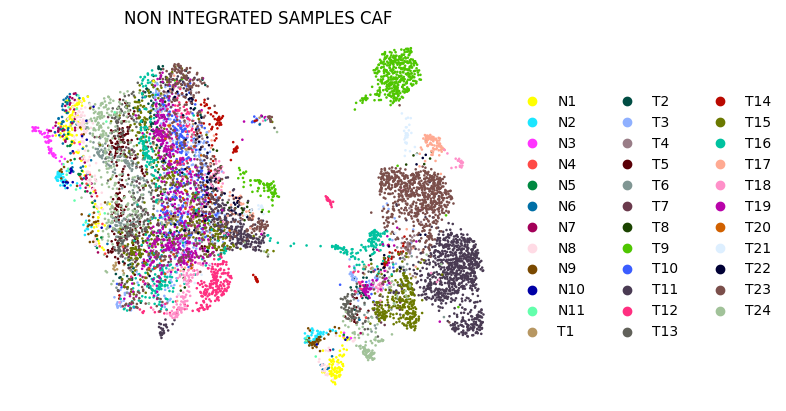

47


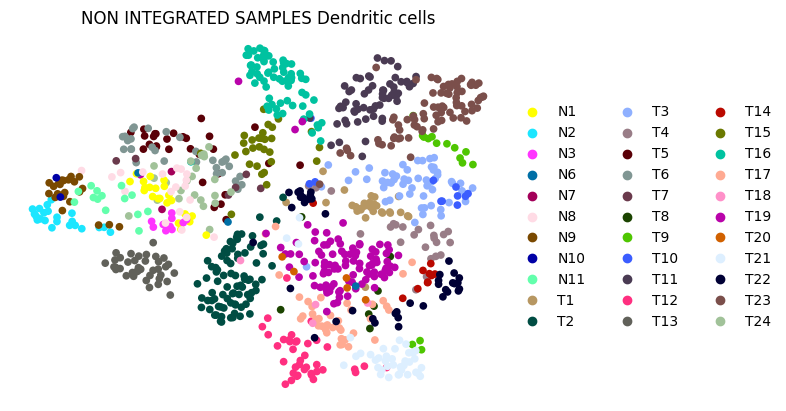

50


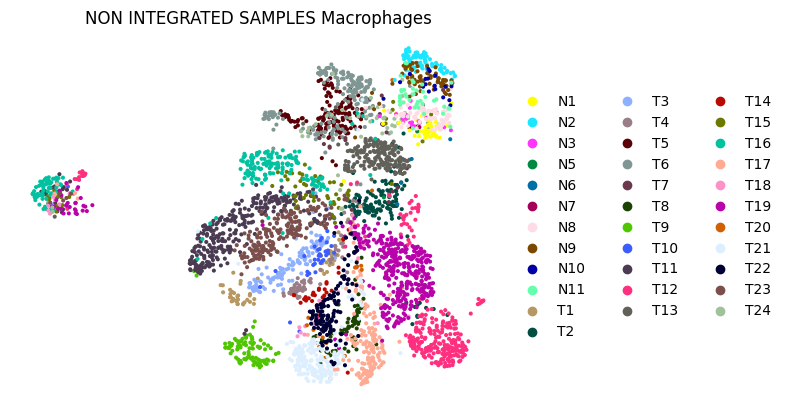

37


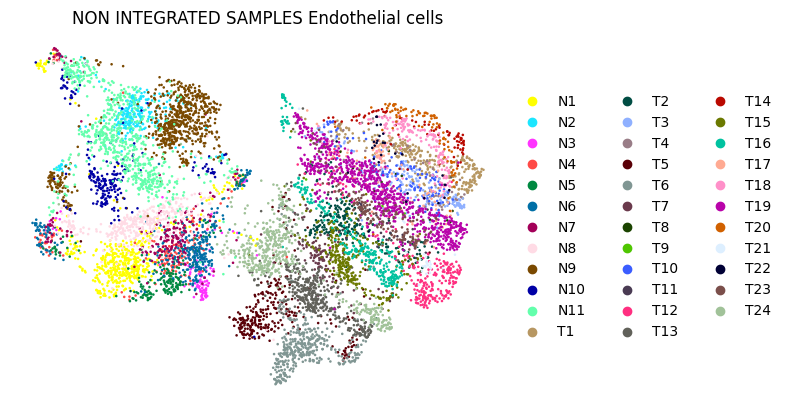

25


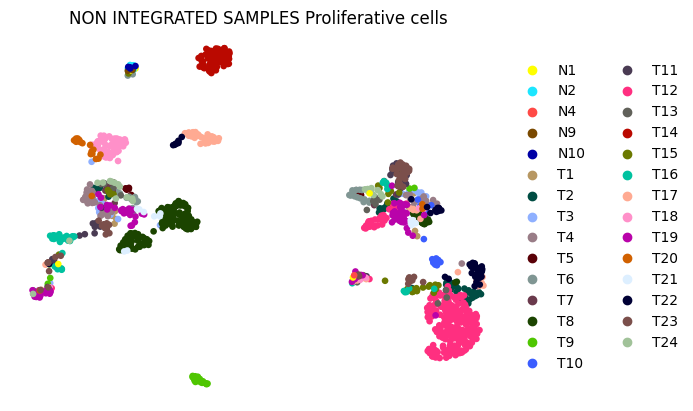

29


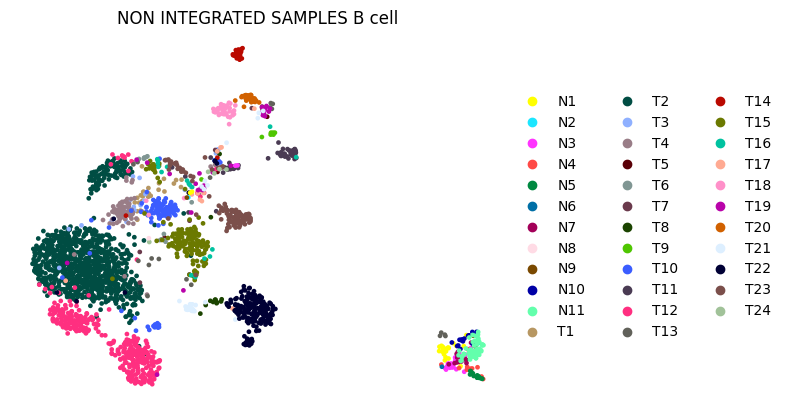

50


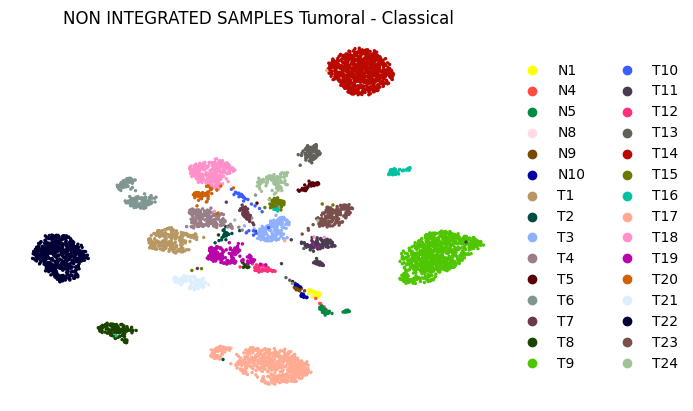

26


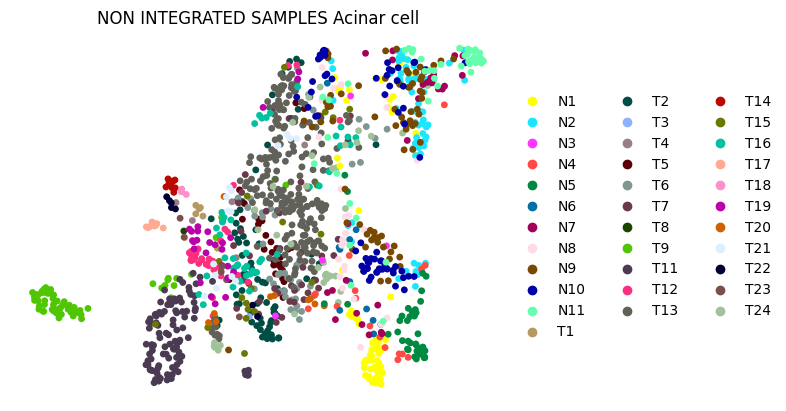

35


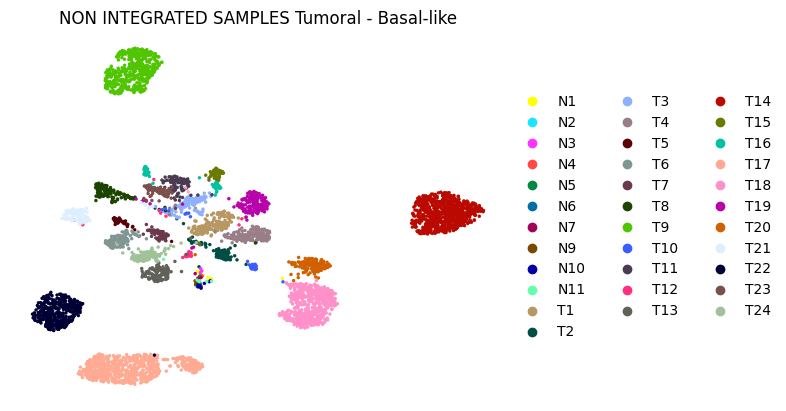

38


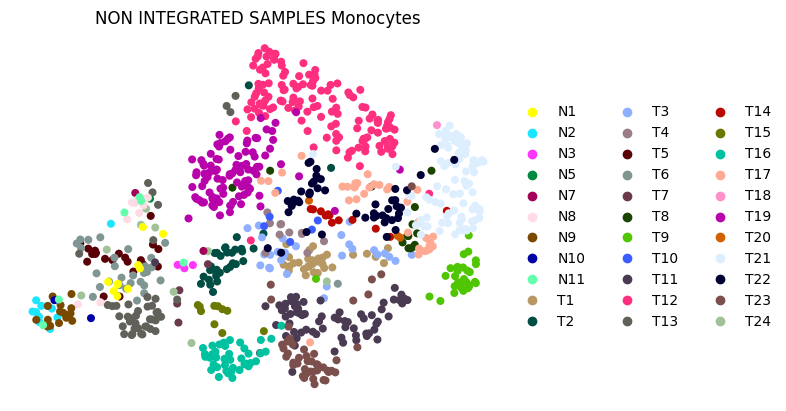

50


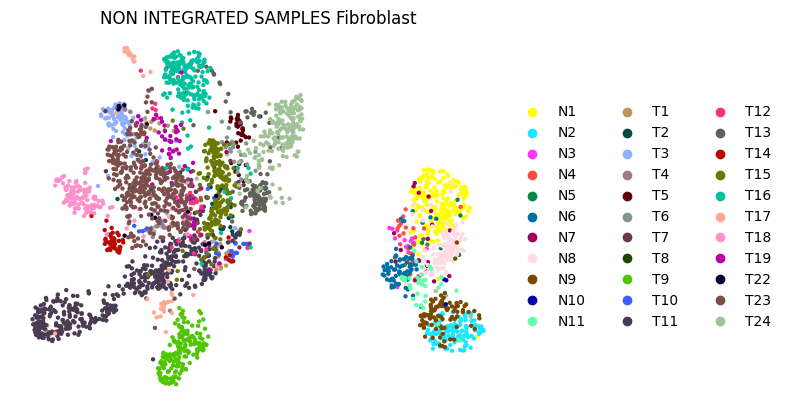

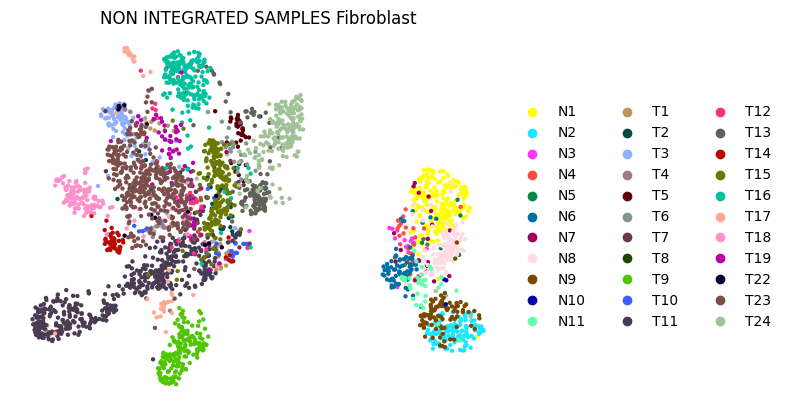

18


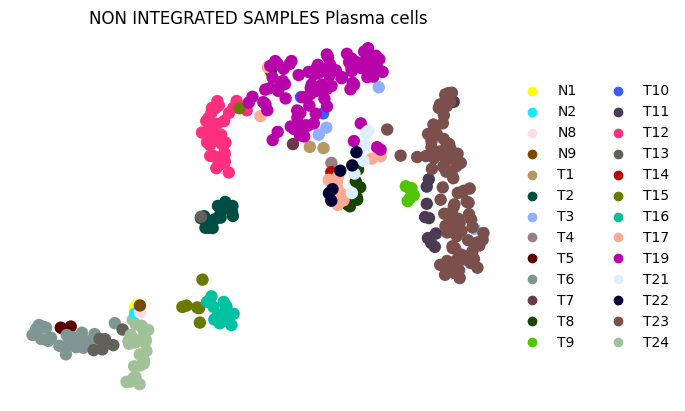

29


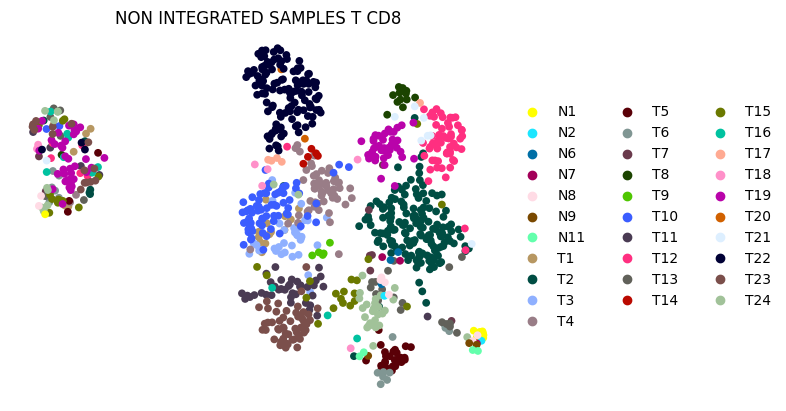

50


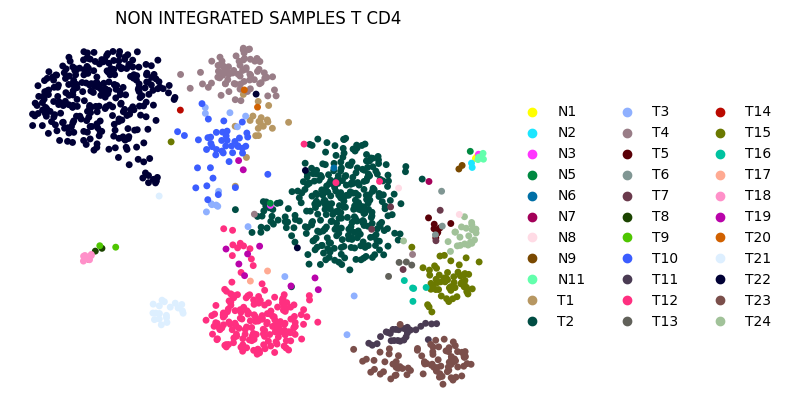

18


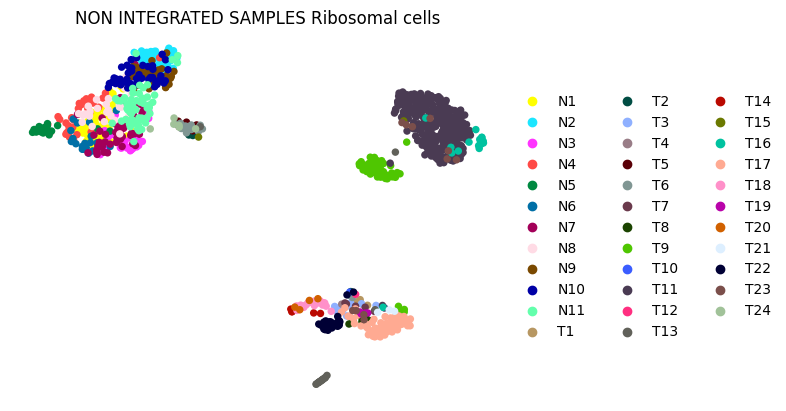

21


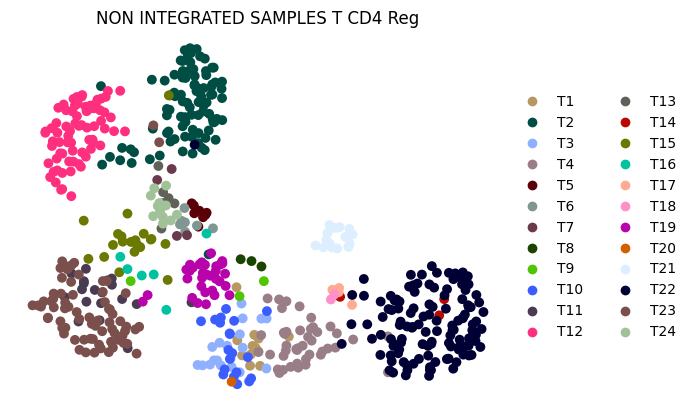

11


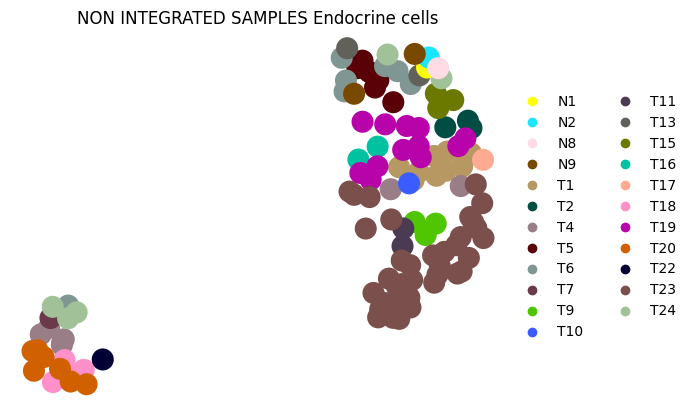

14


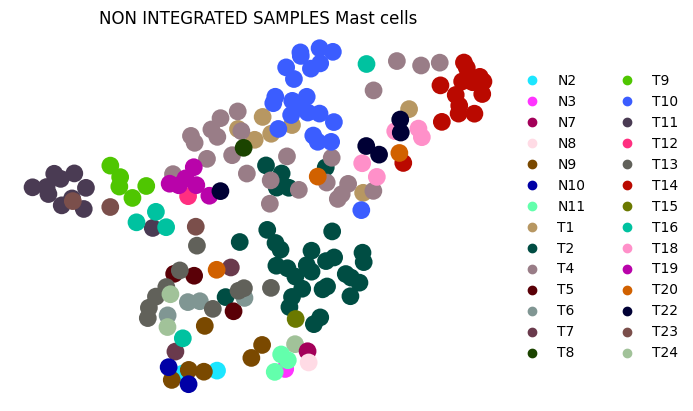

45


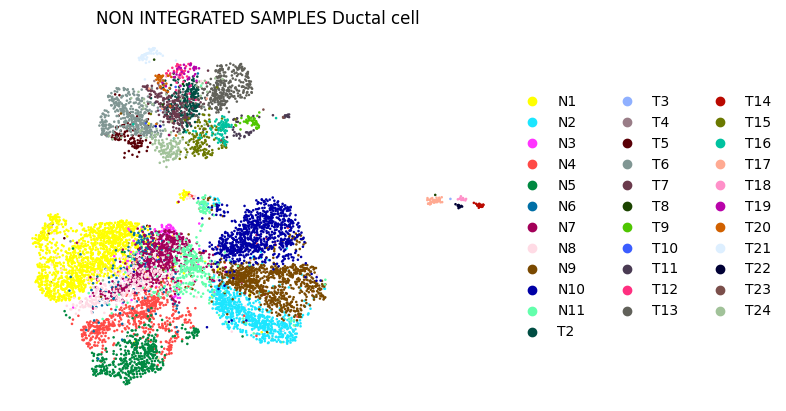

In [18]:
for c_t in list(adata.obs.cell_type.unique()):
    adata_sub = adata[adata.obs["cell_type"] == c_t].copy()

    # Skip if no cells of this type are found
    if adata_sub.n_obs == 0:
        continue

    # Extract cell x gene data from scanpy AnnData and create a pandas DataFrame
    new_frame = pd.DataFrame(adata_sub.X, index=adata_sub.obs_names, columns=adata_sub.var_names)
    pandas_data = new_frame.values

    # Execute PCA elbow fitting function
    dim, new_matrix, pc_ax, pc_ay, col_labels = PCA_Elbow_fit(pandas_data)
    print(dim)

    # Neighbors computation and UMAP
    sc.pp.neighbors(adata_sub, n_pcs=dim)
    sc.tl.umap(adata_sub)

    # Plot UMAP
    sc.pl.umap(adata_sub, color=["Sample"], frameon=False, title=f"NON INTEGRATED SAMPLES {c_t}")

    if c_t == "Fibroblast":
        sc.pl.umap(
            adata_sub,
            color=["Sample"],
            frameon=False,
            title=f"NON INTEGRATED SAMPLES {c_t}",
            save="fibroblast_corr_umap",
        )

In [19]:
#####################################################################################################################

In [20]:
# Subset AnnData to a specific cell type
# Select only cells belonging to the desired cell type (e.g., "Fibroblast")
# and create a copy to avoid modifying the original AnnData object.
desired_type = "Fibroblast"
adata_sub = adata[adata.obs["cell_type"] == desired_type].copy()

In [21]:
# Extract the expression matrix as a pandas DataFrame
# Convert the AnnData expression matrix (.X) into a DataFrame with:
#   - genes as columns
#   - cells as rows
# This facilitates downstream analysis or visualization with pandas or seaborn.

df_expr = pd.DataFrame(
    adata_sub.X if not isinstance(adata_sub.X, pd.DataFrame) else adata_sub.X,
    columns=adata_sub.var_names,
    index=adata_sub.obs_names
)


In [22]:
# Compute top correlated genes within the selected cell type

# Remove genes with zero variance (constant expression),
# as they would produce NaN values in the correlation matrix.
df_expr = df_expr.loc[:, df_expr.var() > 0]

# Compute the full gene–gene correlation matrix.
corr_matrix = df_expr.corr()

# Calculate the mean correlation of each gene with all others.
# The diagonal (self-correlation = 1) is excluded by dividing by (n - 1).
mean_corr = corr_matrix.apply(lambda x: (x.sum() - 1) / (len(x) - 1))

# Select the top N most correlated genes (those with the highest mean correlation).
top_n = 50
top_genes = mean_corr.sort_values(ascending=False).head(top_n).index

# Extract the correlation submatrix for the top correlated genes.
corr_top = df_expr[top_genes].corr()


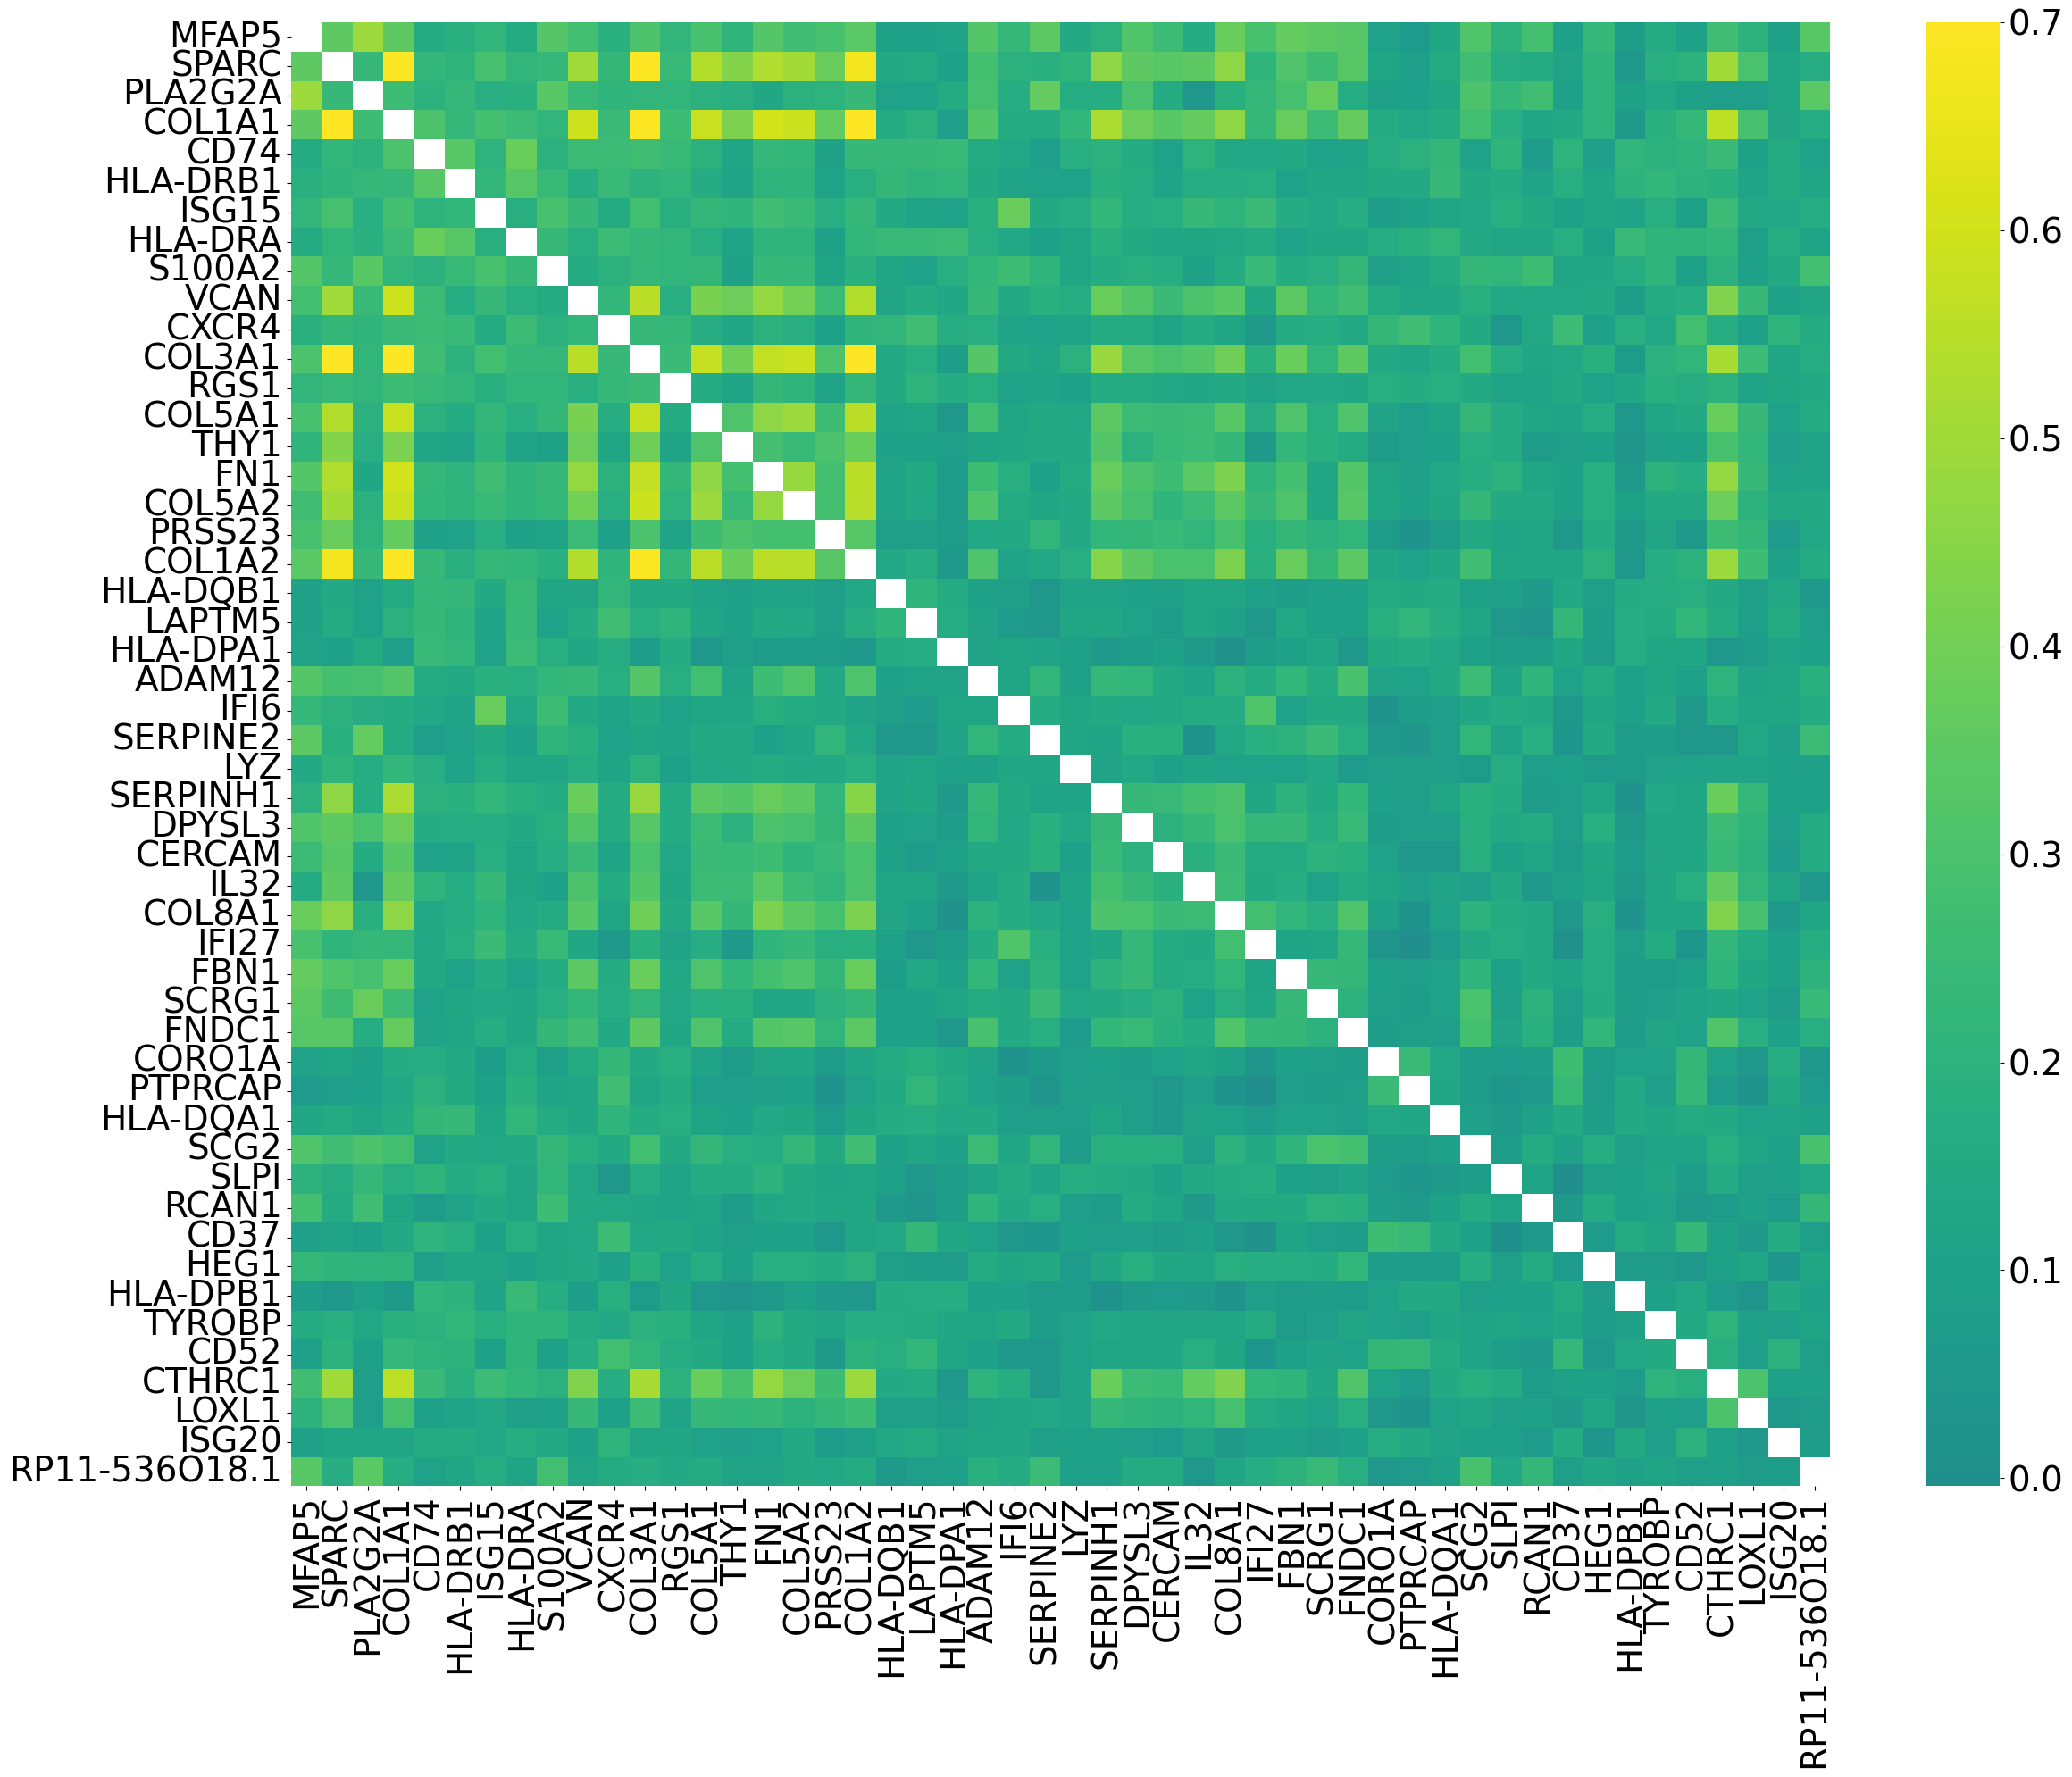

In [ ]:
# Visualize the gene–gene correlation heatmap (top 50 correlated genes)

# Create a copy of the correlation matrix to avoid modifying the original
corr_masked = corr_top.copy()

# Replace the diagonal with NaN values to hide self-correlations (always 1.0)
np.fill_diagonal(corr_masked.values, np.nan)

# Initialize the heatmap figure
plt.figure(figsize=(25, 20))
ax = sns.heatmap(
    corr_masked,
    cmap="viridis",
    center=0,
    vmax=0.7
)

# Adjust tick label sizes and orientation for readability
ax.set_xticklabels(ax.get_xticklabels(), fontsize=28, rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=28, rotation=0)

# Customize colorbar appearance
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=28)

# Layout and export
plt.tight_layout()
plt.savefig("matriz_corr_fibroblast_pearson.png", dpi=300, bbox_inches="tight")
plt.show()